In [4]:
import sqlite3
import pickle
import codecs

import numpy as np
import torch

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import seaborn as sns

from dcase24t6.nn.ckpt import BASELINE_REGISTRY
from dcase24t6.tokenization.aac_tokenizer import AACTokenizer

In [5]:
tokenizer_name_or_path = "baseline_tokenizer"
tokenizer_name = str(tokenizer_name_or_path)
tokenizer_path = BASELINE_REGISTRY.get_path(tokenizer_name)
tokenizer = AACTokenizer.from_file(tokenizer_path)

def createDB(dbName, tableName, colName):
    conn = sqlite3.connect(dbName)
    cursor = conn.cursor()
    sql = f"create table if not exists {tableName} ({colName} string)"
    cursor.execute(sql)
    cursor.close()
    return conn

def countTuples(conn, tableName):
    cursor = conn.cursor()
    rowsCount = cursor.execute(f"select count(*) from {tableName}")
    nrows = next(rowsCount)[0]
    return nrows

def outputTuples(conn, tableName):
    cursor = conn.cursor()
    rows = cursor.execute(f"select * from output")
    for row in rows:
        print(row)

def getTuples(conn, tableName, colName):
    nrows = countTuples(conn, tableName)
    print(f"nrows: {nrows}")
    cursor = conn.cursor()
    sql = f"select mode, epoch, batch_idx, decoding, {colName}, frame_embs, caps_in, tok_embs_outs from {tableName} order by batch_idx desc"
    rows = cursor.execute(sql)
    counter = 1
    mapNum = nrows
    for row in rows:
        weightsTensor = pickle.loads(codecs.decode(row[4].encode(),'base64'))
        frameEmbsTensor = pickle.loads(codecs.decode(row[5].encode(),'base64'))
        capsInTensor = pickle.loads(codecs.decode(row[6].encode(),'base64'))
        tokEmbsOutsTensor = pickle.loads(codecs.decode(row[7].encode(),'base64'))
        # Average the heads
        weightsTensor = weightsTensor.mean(dim=0, keepdim=True)
        print(f"""<mode, epoch, batch_idx, decoding, weights.shape, frame_embs.shape, caps_in.shape tok_embs_outs.shape>: 
              {row[0]}, {str(row[1])}, {str(row[2])}, {row[3]}, {weightsTensor.shape}, {frameEmbsTensor.shape}, {capsInTensor.shape}, {tokEmbsOutsTensor.shape}""")
        if counter == mapNum:    
            # print(tokEmbsOutsTensor)
            plot_attention(weightsTensor[0][0])
        counter += 1
    cursor.close()

def plot_attention(attention, xtitle="Keys", ytitle="Queries"):
    """ Plots the attention map

    Args:
        att (torch.FloatTensor): Attention map (T_q x T_k)
        queries (List[str]): Query Tensor
        keys (List[str]): Key Tensor
    """

    sns.set(rc={'figure.figsize':(20, 8)})
    ax = sns.heatmap(
        attention.detach().cpu(),
        cmap="coolwarm")
        # linewidth=0.5,
        # xticklabels=keys,
        # yticklabels=queries,

    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xlabel(xtitle)
    ax.set_ylabel(ytitle)

Counting tensors
Retrieving tensors
nrows: 15
<mode, epoch, batch_idx, decoding, weights.shape, frame_embs.shape, caps_in.shape tok_embs_outs.shape>: 
              inference, 0, 0, beam, torch.Size([1, 3, 1, 192]), torch.Size([192, 3, 256]), torch.Size([1, 3, 256]), torch.Size([1, 3, 256])
<mode, epoch, batch_idx, decoding, weights.shape, frame_embs.shape, caps_in.shape tok_embs_outs.shape>: 
              inference, 0, 0, beam, torch.Size([1, 3, 2, 192]), torch.Size([192, 3, 256]), torch.Size([2, 3, 256]), torch.Size([2, 3, 256])
<mode, epoch, batch_idx, decoding, weights.shape, frame_embs.shape, caps_in.shape tok_embs_outs.shape>: 
              inference, 0, 0, beam, torch.Size([1, 3, 3, 192]), torch.Size([192, 3, 256]), torch.Size([3, 3, 256]), torch.Size([3, 3, 256])
<mode, epoch, batch_idx, decoding, weights.shape, frame_embs.shape, caps_in.shape tok_embs_outs.shape>: 
              inference, 0, 0, beam, torch.Size([1, 3, 4, 192]), torch.Size([192, 3, 256]), torch.Size([4, 3, 2

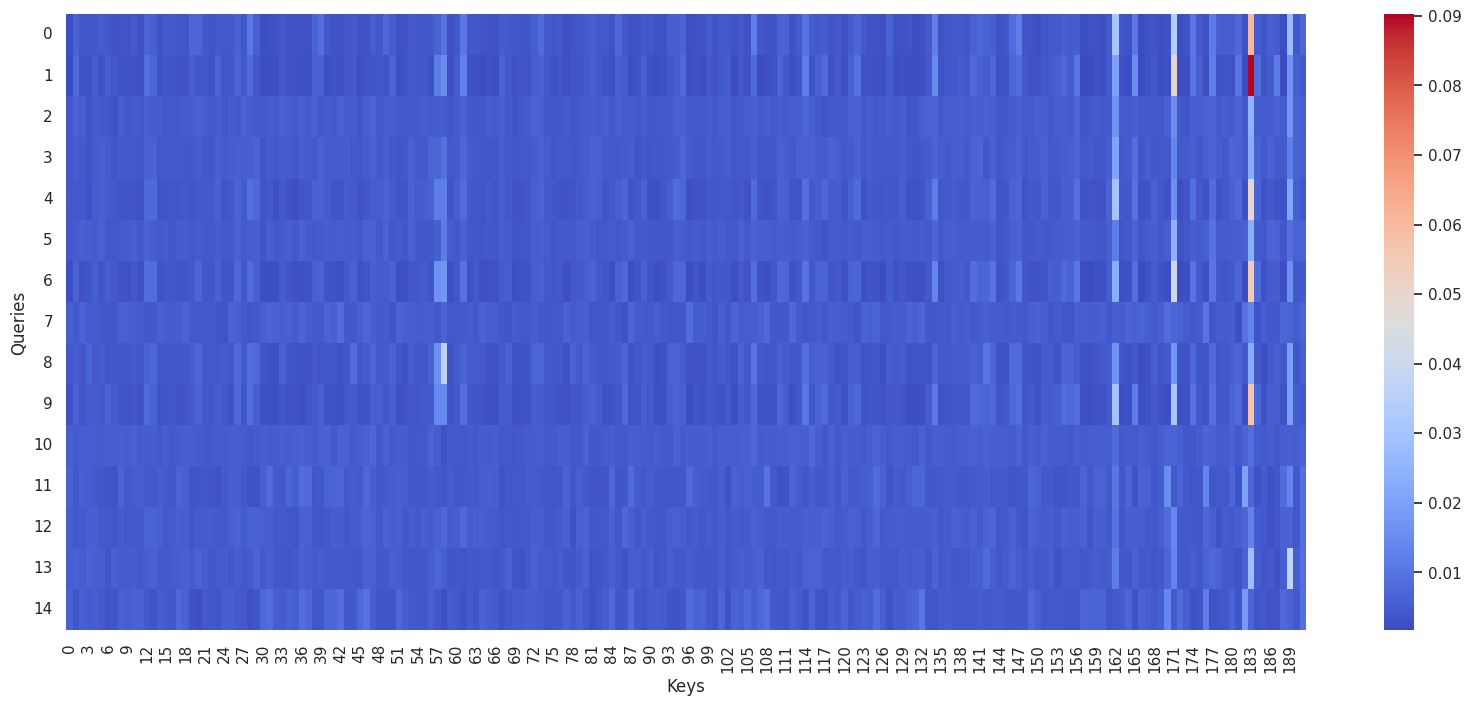

In [6]:
# 'La Vie en Rose' -> 'a trumpet is playing a song , then a person plays a second joins in the background'
# dbName = "/home/victorcuevasv/upc-dl-2025/demo/attn-fc698018-dc46-472a-be23-c47cfd441c27.db"
# 'Die Fledermaus' -> 'a musical instrument is playing a song with a nice melody in the background'
dbName = "/home/victorcuevasv/upc-dl-2025/demo/attn-a1335b87-26b9-4b6c-b4fd-dd0fbcc6f4ce.db"
tableName = "weights"
colName = "weights"
conn = createDB(dbName, tableName, colName)
print("Counting tensors")
countTuples(conn, tableName)
print("Retrieving tensors")
getTuples(conn, tableName, colName)
outputTuples(conn, "output")